# Diabetic Retinopathy Detection (Binary + Grad-CAM)

In [1]:
# CONFIG
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-4


In [2]:
# Imports
import os, cv2, numpy as np, pandas as pd, torch, torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Dataset Path Auto Detection
BASE = '/kaggle/input'
DATASET_PATH = None
for root, dirs, files in os.walk(BASE):
    if 'train_1.csv' in files:
        DATASET_PATH = root
        break
print('Dataset:', DATASET_PATH)


Dataset: /kaggle/input/datasets/mariaherrerot/aptos2019


In [4]:
# Load CSV
train_df = pd.read_csv(os.path.join(DATASET_PATH, 'train_1.csv'))
val_df = pd.read_csv(os.path.join(DATASET_PATH, 'valid.csv'))
test_df = pd.read_csv(os.path.join(DATASET_PATH, 'test.csv'))

# Binary mapping
train_df['label'] = train_df['diagnosis'].apply(lambda x: 0 if x==0 else 1)
val_df['label'] = val_df['diagnosis'].apply(lambda x: 0 if x==0 else 1)
test_df['label'] = test_df['diagnosis'].apply(lambda x: 0 if x==0 else 1)


In [5]:
# Preprocessing (Ben Graham)
def preprocess(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    blur = cv2.GaussianBlur(img,(0,0),10)
    img = cv2.addWeighted(img,4,blur,-4,128)
    return img


In [6]:
# Dataset Class
class DRDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['id_code']+'.png')
        img = preprocess(img_path)
        if self.transform: img = self.transform(img)
        return img, torch.tensor(row['label']).float()


In [7]:
# Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [8]:
# Paths
train_dir = os.path.join(DATASET_PATH,'train_images','train_images')
val_dir = os.path.join(DATASET_PATH,'val_images','val_images')
test_dir = os.path.join(DATASET_PATH,'test_images','test_images')


In [9]:
# Loaders
train_loader = DataLoader(DRDataset(train_df,train_dir,transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(DRDataset(val_df,val_dir,transform), batch_size=BATCH_SIZE)
test_loader = DataLoader(DRDataset(test_df,test_dir,transform), batch_size=BATCH_SIZE)


In [10]:
# Model
model = models.efficientnet_b4(weights='DEFAULT')
model.classifier[1] = nn.Linear(model.classifier[1].in_features,1)
model = model.cuda()


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 198MB/s] 


In [11]:
# Loss + Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


In [12]:
# Training Loop
best_kappa = 0
for epoch in range(EPOCHS):
    model.train()
    for x,y in train_loader:
        x,y = x.cuda(), y.cuda().unsqueeze(1)
        out = model(x)
        loss = criterion(out,y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

    # Validation
    model.eval(); preds=[]; labels=[]
    with torch.no_grad():
        for x,y in val_loader:
            x = x.cuda()
            out = torch.sigmoid(model(x))
            p = (out>0.5).cpu().numpy()
            preds.extend(p)
            labels.extend(y.numpy())

    kappa = cohen_kappa_score(labels,preds)
    print('Epoch',epoch,'Kappa',kappa)
    if kappa>best_kappa:
        best_kappa = kappa
        torch.save(model.state_dict(),'/kaggle/working/best_model.pth')


Epoch 0 Kappa 0.9235223880597014
Epoch 1 Kappa 0.9398511967012281
Epoch 2 Kappa 0.9615972659411818
Epoch 3 Kappa 0.9780628146727404
Epoch 4 Kappa 0.9562122390381049
Epoch 5 Kappa 0.9780628146727404
Epoch 6 Kappa 0.9671159029649595
Epoch 7 Kappa 0.9670725124452708
Epoch 8 Kappa 0.9726056106104608
Epoch 9 Kappa 0.9616225770694149
Epoch 10 Kappa 0.9726056106104608
Epoch 11 Kappa 0.9780772686433064
Epoch 12 Kappa 0.956096683260361
Epoch 13 Kappa 0.9670942220091105
Epoch 14 Kappa 0.9780772686433064
Epoch 15 Kappa 0.9780772686433064
Epoch 16 Kappa 0.9725513724313785


KeyboardInterrupt: 

Accuracy: 0.9754098360655737 AUC: 0.9754611380254566 Kappa: 0.9504646756293422


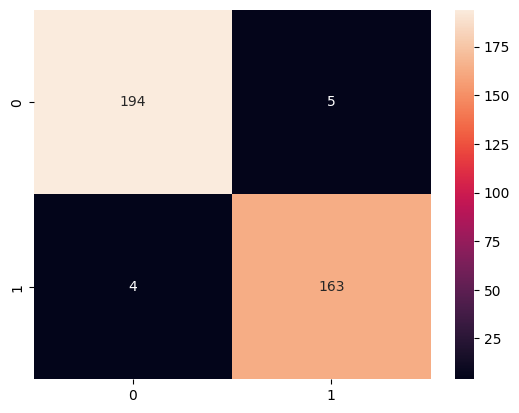

In [13]:
# Evaluation
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
model.eval(); preds=[]; labels=[]

with torch.no_grad():
    for x,y in test_loader:
        x = x.cuda()
        out = torch.sigmoid(model(x))
        p = (out>0.5).cpu().numpy()
        preds.extend(p)
        labels.extend(y.numpy())

acc = accuracy_score(labels,preds)
auc = roc_auc_score(labels,preds)
kappa = cohen_kappa_score(labels,preds)
cm = confusion_matrix(labels,preds)

print('Accuracy:',acc,'AUC:',auc,'Kappa:',kappa)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()


# *Run 2*** 

In [1]:
#Shit here we go again...stoped the session with GPU and started with only CPU. uploaded my model as dataset
import torch
import torch.nn as nn
from torchvision import models

In [2]:
model = models.efficientnet_b4(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model = model.to('cpu')

model.load_state_dict(
    torch.load(
        '/kaggle/input/datasets/parthag9/dr-efficientnet-b4-model/best_model.pth',
        map_location=torch.device('cpu')
    )
)

model.eval()
print("Model loaded successfully")

Model loaded successfully


In [3]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [4]:
print(os.listdir("/kaggle/input/datasets"))

['parthag9', 'mariaherrerot']


In [5]:
print(os.listdir("/kaggle/input/datasets/parthag9"))

['dr-efficientnet-b4-model']


In [6]:
#solving error in evaluation again
#import
import pandas as pd
import os
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

#Transform (same as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # same as training
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [7]:
#Dataset class
class DRDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['id_code']
        label = self.df.iloc[idx]['diagnosis']

        img_path = os.path.join(img_dir, img_name + ".png")
        image = Image.open(img_path).convert("RGB")

        image = self.transform(image)

        # binary conversion
        label = 0 if label == 0 else 1

        return image, label

In [8]:
df = pd.read_csv('/kaggle/input/datasets/mariaherrerot/aptos2019/train_1.csv')
val_df = pd.read_csv('/kaggle/input/datasets/mariaherrerot/aptos2019/valid.csv')

In [9]:
class DRDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['id_code']
        label = self.df.iloc[idx]['diagnosis']

        # ✅ FIX HERE
        img_path = os.path.join(self.img_dir, img_name + ".png")

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        # binary conversion
        label = 0 if label == 0 else 1

        return image, label

In [10]:
TRAIN_IMG_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images"
VAL_IMG_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images"

val_dataset = DRDataset(val_df, VAL_IMG_DIR, transform)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
print(os.listdir(TRAIN_IMG_DIR)[:5])

['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png', '8d13c46e7d75.png', 'c3b15bf9b4bc.png']


##  **for run 3 run till here dont run the next cell. i am not gonna write same shit again...**

In [15]:
#evaluation again
import torch
import numpy as np
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, roc_auc_score

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:   # use your validation loader
        images = images.to('cpu')
        labels = labels.to('cpu')

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze()

        preds = (probs > 0.3).int()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.numpy())

# Convert to numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

In [16]:
#Printing metrics...aaaaahhh
accuracy = accuracy_score(all_labels, all_preds)
kappa = cohen_kappa_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print(f"Accuracy: {accuracy:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC: {auc:.4f}")

Accuracy: 0.9481
Kappa: 0.8964
AUC: 0.9919


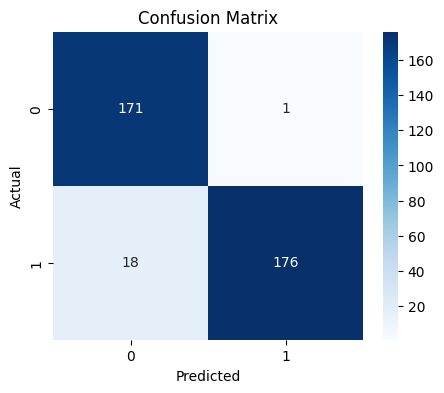

In [17]:
#confusion matric
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [18]:
# Grad-CAM (basic placeholder)
print('Grad-CAM visualization step here')


Grad-CAM visualization step here


In [19]:
target_layer = model.features[-1]

In [20]:
#Grad-CAM class
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image):
        output = self.model(input_image)
        self.model.zero_grad()

        output.backward()

        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()

        weights = np.mean(gradients, axis=(1, 2))

        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)

        return cam

In [23]:
#Visualization function
def show_gradcam(image, cam):
    image = image.permute(1,2,0).cpu().numpy()

    # 🔥 UNNORMALIZE (important)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    overlay = heatmap + image
    overlay = overlay / np.max(overlay)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(image)
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Heatmap")
    plt.imshow(cam, cmap='jet')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis('off')

    plt.show()

Actual: 1 | Predicted: 1 | Prob: 0.991


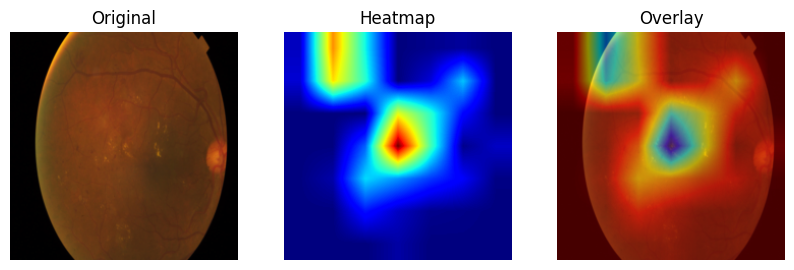

Actual: 1 | Predicted: 1 | Prob: 0.970


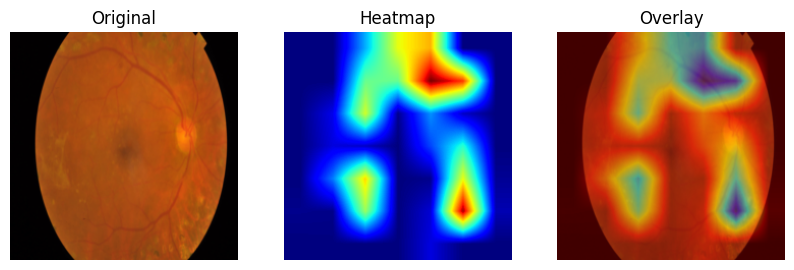

Actual: 1 | Predicted: 1 | Prob: 0.501


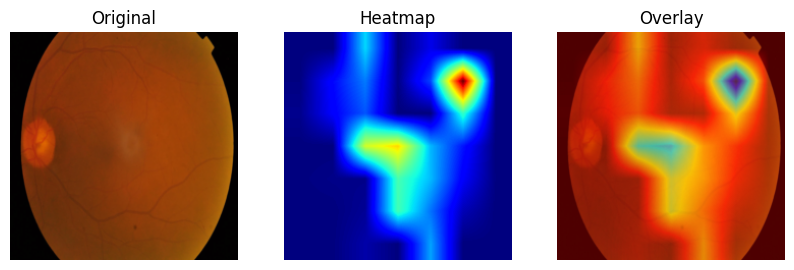

Actual: 0 | Predicted: 0 | Prob: 0.000


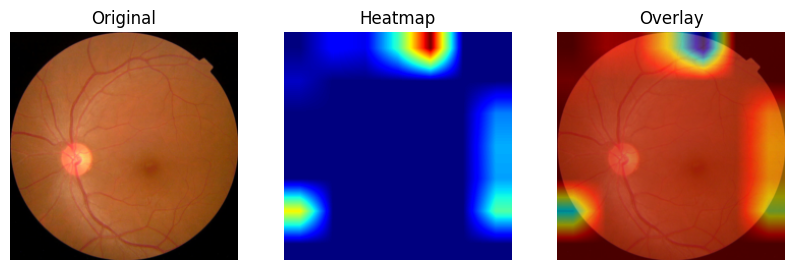

Actual: 0 | Predicted: 0 | Prob: 0.000


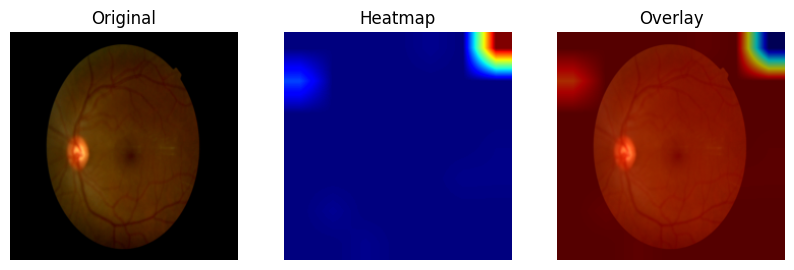

In [25]:
gradcam = GradCAM(model, target_layer)

model.eval()

count = 0

for images, labels in val_loader:
    images = images.to('cpu')
    labels = labels.to('cpu')

    for i in range(images.size(0)):
        img = images[i].unsqueeze(0)

        # 🔥 Forward pass
        output = model(img)
        prob = torch.sigmoid(output)
        pred = (prob > 0.3).int()   # use your optimized threshold

        # 🔥 Generate Grad-CAM
        cam = gradcam.generate(img)

        # 🔥 Print useful info
        print(f"Actual: {labels[i].item()} | Predicted: {pred.item()} | Prob: {prob.item():.3f}")

        # 🔥 Show visualization
        show_gradcam(images[i], cam)

        count += 1
        if count >= 5:
            break
    if count >= 5:
        break

# *run 3*** -->
> if running from here make sure val_df is still in memory (it was loaded in Run 2). If you restarted kernel again, re-run just that CSV loading cell first.
> if you didn't understand what the fuck is that just scroll up until you see run 2 start running from there to the part before evaluation again. dont run evaluation again cell

In [11]:
# CELL 1: Ben Graham preprocessing — MUST match training exactly
import cv2
import numpy as np

def preprocess_bengrah(img):
    # img is a PIL Image — convert to numpy first
    img = np.array(img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    blur = cv2.GaussianBlur(img, (0, 0), 10)
    img = cv2.addWeighted(img, 4, blur, -4, 128)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [12]:
# CELL 2: Dataset with correct preprocessing
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class DRDatasetFixed(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['id_code']
        label    = self.df.iloc[idx]['diagnosis']

        img_path = os.path.join(self.img_dir, img_name + ".png")
        image    = Image.open(img_path).convert("RGB")

        # Ben Graham applied here — same as training
        image = preprocess_bengrah(image)
        image = self.transform(image)

        label = 0 if label == 0 else 1
        return image, label

In [13]:
# CELL 3: Rebuild val loader with fixed dataset
VAL_IMG_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images"

val_dataset_fixed = DRDatasetFixed(val_df, VAL_IMG_DIR, transform)
val_loader_fixed  = DataLoader(val_dataset_fixed, batch_size=8, shuffle=False)

print(f"Val samples: {len(val_dataset_fixed)}")

Val samples: 366


In [14]:
# CELL 4: Evaluation — threshold 0.3 (intentional: reduces false negatives for DR)
import torch
import numpy as np
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, confusion_matrix

THRESHOLD = 0.3

model.eval()
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in val_loader_fixed:
        images = images.to('cpu')
        outputs = model(images)
        probs   = torch.sigmoid(outputs).squeeze()

        preds = (probs > THRESHOLD).int()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

accuracy = accuracy_score(all_labels, all_preds)
kappa    = cohen_kappa_score(all_labels, all_preds)
auc      = roc_auc_score(all_labels, all_probs)

print(f"Threshold : {THRESHOLD}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Kappa     : {kappa:.4f}")
print(f"AUC       : {auc:.4f}")

Threshold : 0.3
Accuracy  : 0.9863
Kappa     : 0.9726
AUC       : 0.9955


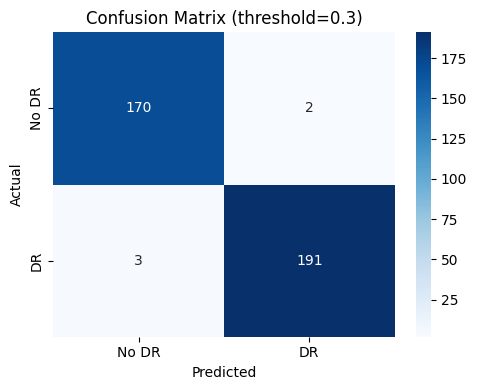


True Negatives  (correctly said No DR): 170
True Positives  (correctly said DR)   : 191
False Positives (wrongly said DR)     : 2
False Negatives (missed DR cases)     : 3

Sensitivity (recall for DR): 0.9845
Specificity (recall for No DR): 0.9884


In [15]:
# CELL 5: Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No DR', 'DR'],
            yticklabels=['No DR', 'DR'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

# Breakdown for examiner
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly said No DR): {tn}")
print(f"True Positives  (correctly said DR)   : {tp}")
print(f"False Positives (wrongly said DR)     : {fp}")
print(f"False Negatives (missed DR cases)     : {fn}")
print(f"\nSensitivity (recall for DR): {tp/(tp+fn):.4f}")
print(f"Specificity (recall for No DR): {tn/(tn+fp):.4f}")

In [16]:
# CELL 6: Fixed Grad-CAM (register_full_backward_hook — not deprecated)
import torch
import cv2
import numpy as np

class GradCAMFixed:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None

        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_image):
        output = self.model(input_image)
        self.model.zero_grad()
        output.backward()

        gradients  = self.gradients[0].cpu().numpy()   # shape: (C, H, W)
        activations = self.activations[0].cpu().numpy() # shape: (C, H, W)

        weights = np.mean(gradients, axis=(1, 2))       # global average pooling

        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)                        # ReLU
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # normalize safely

        return cam, output

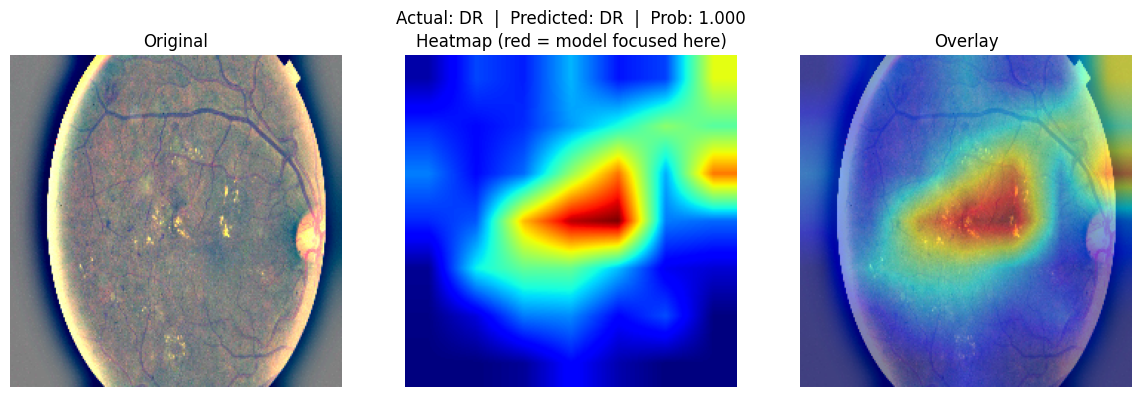

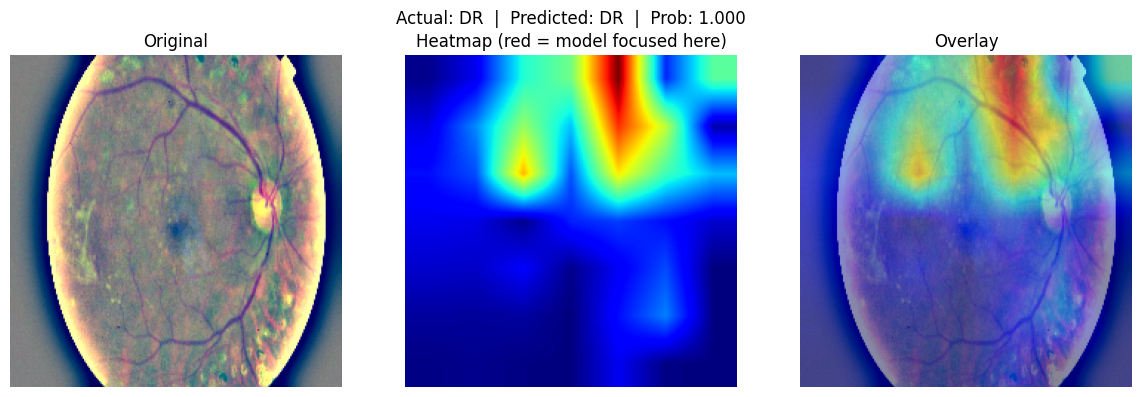

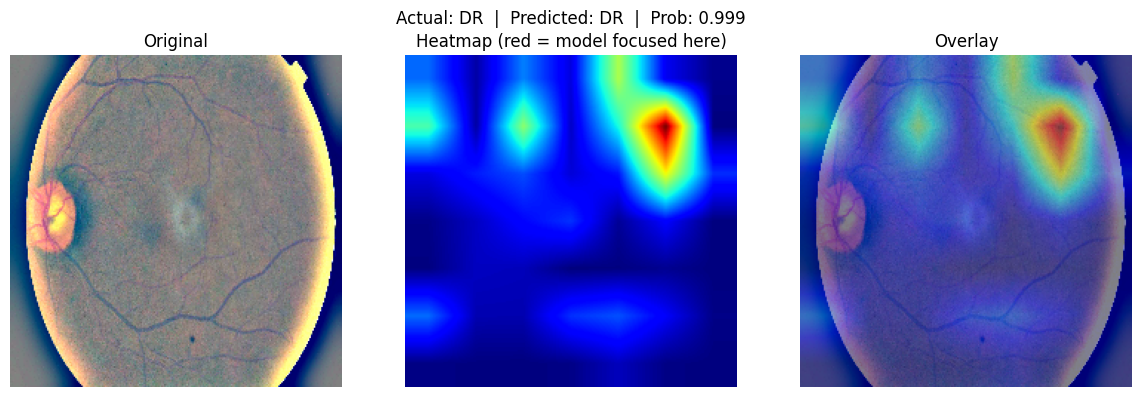

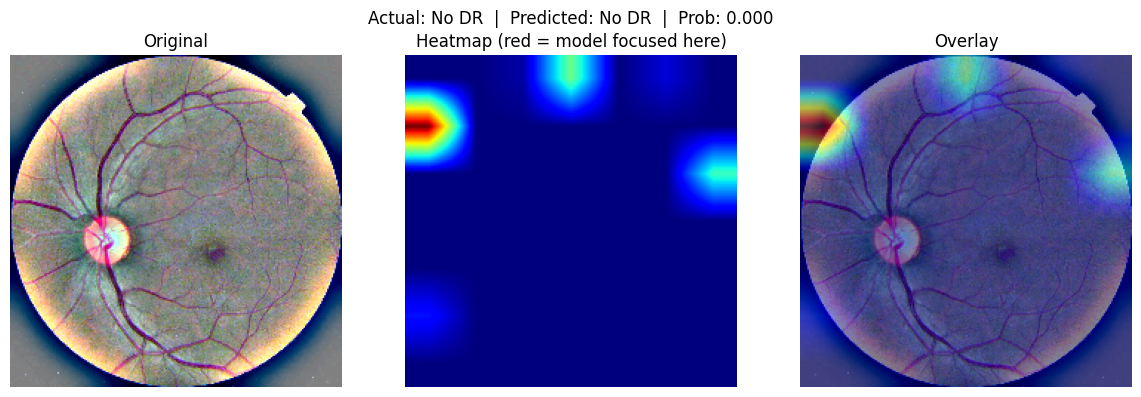

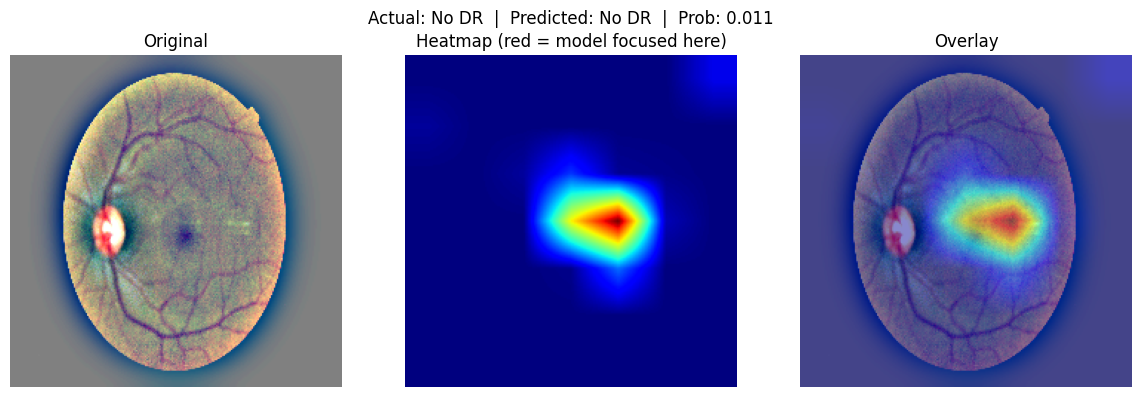

In [17]:
# CELL 7: Grad-CAM visualization on 5 validation images
def show_gradcam(image_tensor, cam, actual, predicted, prob):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()

    # Unnormalize
    mean  = np.array([0.485, 0.456, 0.406])
    std   = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = np.float32(heatmap) / 255

    overlay = heatmap + image
    overlay = overlay / overlay.max()

    label_map = {0: "No DR", 1: "DR"}

    plt.figure(figsize=(12, 4))
    plt.suptitle(
        f"Actual: {label_map[actual]}  |  Predicted: {label_map[predicted]}  |  Prob: {prob:.3f}",
        fontsize=12
    )

    plt.subplot(1, 3, 1); plt.title("Original")
    plt.imshow(image);    plt.axis('off')

    plt.subplot(1, 3, 2); plt.title("Heatmap (red = model focused here)")
    plt.imshow(cam, cmap='jet'); plt.axis('off')

    plt.subplot(1, 3, 3); plt.title("Overlay")
    plt.imshow(overlay);  plt.axis('off')

    plt.tight_layout()
    plt.show()


# --- Run ---
target_layer = model.features[-1]
gradcam      = GradCAMFixed(model, target_layer)

model.eval()
count = 0

for images, labels in val_loader_fixed:
    images = images.to('cpu')

    for i in range(images.size(0)):
        img = images[i].unsqueeze(0).requires_grad_(True)

        cam, output = gradcam.generate(img)

        prob      = torch.sigmoid(output).item()
        predicted = 1 if prob > THRESHOLD else 0
        actual    = labels[i].item()

        show_gradcam(images[i], cam, actual, predicted, prob)

        count += 1
        if count >= 5:
            break
    if count >= 5:
        break